---
## PART A: Train Baseline Models (~1 hour)

In [3]:

from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted!


In [4]:

!pip install -q scikit-learn seaborn

print("✓ Packages installed!")

✓ Packages installed!


In [5]:
# 3. Keep-alive script
from IPython.display import display, Javascript
import threading, time

def keep_alive():
    while True:
        try:
            display(Javascript('console.log("Active: " + new Date().toLocaleTimeString())'))
            time.sleep(300)
        except:
            break

threading.Thread(target=keep_alive, daemon=True).start()
print("✓ Keep-alive running!")

✓ Keep-alive running!


<IPython.core.display.Javascript object>

In [6]:
# 4. Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# 5. Load data from Phase 2
data_path = "/content/drive/MyDrive/dataforproject/"

x_train = np.load(data_path + 'x_train_normalized.npy')
y_train = np.load(data_path + 'y_train_onehot.npy')
x_test = np.load(data_path + 'x_test_normalized.npy')
y_test = np.load(data_path + 'y_test_onehot.npy')

# Train/val split
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

print(f"✓ Data loaded: Train {x_train_final.shape}, Val {x_val.shape}, Test {x_test.shape}")

✓ Data loaded: Train (40000, 32, 32, 3), Val (10000, 32, 32, 3), Test (10000, 32, 32, 3)


In [8]:
# 6. Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("✓ Data augmentation ready")

✓ Data augmentation ready


### Baseline 1: Simple CNN (~15 minutes)

In [9]:
# Build Simple CNN
def build_simple_cnn():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='SimpleCNN')

simple_cnn = build_simple_cnn()
simple_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Simple CNN - Parameters: {simple_cnn.count_params():,}")

Simple CNN - Parameters: 122,570


In [ ]:
# Train Simple CNN
print("Training Simple CNN... (~15 min)")

history_cnn = simple_cnn.fit(
    x_train_final, y_train_final,
    batch_size=64,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(data_path + 'simple_cnn_best.h5', save_best_only=True)
    ],
    verbose=1
)

cnn_loss, cnn_acc = simple_cnn.evaluate(x_test, y_test, verbose=0)
print(f"\n✓ Simple CNN Test Accuracy: {cnn_acc*100:.2f}%")

Training Simple CNN... (~15 min)
Epoch 1/30
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2141 - loss: 2.0989

625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.2851 - loss: 1.9387 - val_accuracy: 0.4313 - val_loss: 1.5509
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3821 - loss: 1.6775

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3997 - loss: 1.6389 - val_accuracy: 0.4849 - val_loss: 1.4109
Epoch 3/30
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4351 - loss: 1.5568

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4451 - loss: 1.5377 - val_accuracy: 0.5298 - val_loss: 1.3208
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4696 - loss: 1.4770

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4764 - loss: 1.4571 - val_accuracy: 0.5624 - val_loss: 1.2567
Epoch 5/30
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4944 - loss: 1.4199

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6104 - loss: 1.1109 - val_accuracy: 0.6770 - val_loss: 0.9572
Epoch 19/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6118 - loss: 1.1186

625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6158 - loss: 1.1043 - val_accuracy: 0.6696 - val_loss: 0.9527
Epoch 20/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6133 - loss: 1.1166

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6145 - loss: 1.1095 - val_accuracy: 0.6839 - val_loss: 0.9166
Epoch 21/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6183 - loss: 1.0899 - val_accuracy: 0.6710 - val_loss: 0.9554
Epoch 22/30
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6162 - loss: 1.1000

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6202 - loss: 1.0888 - val_accuracy: 0.6836 - val_loss: 0.9100
Epoch 23/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6259 - loss: 1.0789 - val_accuracy: 0.6717 - val_loss: 0.9464
Epoch 24/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6263 - loss: 1.0710 - val_accuracy: 0.6722 - val_loss: 0.9387
Epoch 25/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6298 - loss: 1.0622 - val_accuracy: 0.6873 - val_loss: 0.9229
Epoch 26/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6311 - loss: 1.0584 - val_accuracy: 0.6789 - val_loss: 0.9488
Epoch 27/30
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6278 - loss: 1.0660

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6327 - loss: 1.0595 - val_accuracy: 0.6906 - val_loss: 0.8955
Epoch 28/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6371 - loss: 1.0472 - val_accuracy: 0.6826 - val_loss: 0.9157
Epoch 29/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6419 - loss: 1.0362 - val_accuracy: 0.6799 - val_loss: 0.9374
Epoch 30/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6414 - loss: 1.0361 - val_accuracy: 0.6813 - val_loss: 0.9571

✓ Simple CNN Test Accuracy: 69.80%


### Baseline 2: ResNet-18 (~45-60 minutes)

In [11]:
# Build ResNet-18
def residual_block(x, filters, stride=1, conv_shortcut=False, name=None):
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, name=name+'_0_conv')(x)
        shortcut = layers.BatchNormalization(name=name+'_0_bn')(shortcut)
    else:
        shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', name=name+'_1_conv')(x)
    x = layers.BatchNormalization(name=name+'_1_bn')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', name=name+'_2_conv')(x)
    x = layers.BatchNormalization(name=name+'_2_bn')(x)

    x = layers.Add()([shortcut, x])
    x = layers.Activation('relu')(x)
    return x

def build_resnet18():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64, name='conv2_block1')
    x = residual_block(x, 64, name='conv2_block2')
    x = residual_block(x, 128, stride=2, conv_shortcut=True, name='conv3_block1')
    x = residual_block(x, 128, name='conv3_block2')
    x = residual_block(x, 256, stride=2, conv_shortcut=True, name='conv4_block1')
    x = residual_block(x, 256, name='conv4_block2')
    x = residual_block(x, 512, stride=2, conv_shortcut=True, name='conv5_block1')
    x = residual_block(x, 512, name='conv5_block2')

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='ResNet18')

resnet18 = build_resnet18()
resnet18.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"ResNet-18 - Parameters: {resnet18.count_params():,}")

ResNet-18 - Parameters: 11,188,362


In [12]:
# Train ResNet-18
print("Training ResNet-18... (~45-60 min)")

history_resnet = resnet18.fit(
    x_train_final, y_train_final,
    batch_size=64,
    epochs=40,
    validation_data=(x_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(data_path + 'resnet18_best.h5', save_best_only=True)
    ],
    verbose=1
)

resnet_loss, resnet_acc = resnet18.evaluate(x_test, y_test, verbose=0)
print(f"\n✓ ResNet-18 Test Accuracy: {resnet_acc*100:.2f}%")

Training ResNet-18... (~45-60 min)
Epoch 1/40
523/625 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2950 - loss: 2.1896

<IPython.core.display.Javascript object>

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3071 - loss: 2.1329

625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - accuracy: 0.3773 - loss: 1.8128 - val_accuracy: 0.3522 - val_loss: 2.1169
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.5214 - loss: 1.3419 - val_accuracy: 0.3953 - val_loss: 2.3917
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5830 - loss: 1.1753

625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.5993 - loss: 1.1299 - val_accuracy: 0.5524 - val_loss: 1.4355
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6515 - loss: 0.9989

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9096 - loss: 0.2630 - val_accuracy: 0.8645 - val_loss: 0.4522
Epoch 24/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.9152 - loss: 0.2465 - val_accuracy: 0.8337 - val_loss: 0.5688
Epoch 25/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.9185 - loss: 0.2331 - val_accuracy: 0.8577 - val_loss: 0.4885
Epoch 26/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9233 - loss: 0.2216 - val_accuracy: 0.8565 - val_loss: 0.5125
Epoch 27/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9250 - loss: 0.2184

<IPython.core.display.Javascript object>

625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9262 - loss: 0.2128 - val_accuracy: 0.8404 - val_loss: 0.5852
Epoch 28/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.9284 - loss: 0.2034 - val_accuracy: 0.8594 - val_loss: 0.4851
Epoch 29/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9345 - loss: 0.1882 - val_accuracy: 0.8473 - val_loss: 0.5802
Epoch 30/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9359 - loss: 0.1835 - val_accuracy: 0.8590 - val_loss: 0.4888
Epoch 31/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9378 - loss: 0.1770 - val_accuracy: 0.8595 - val_loss: 0.5226
Epoch 32/40
396/625 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.9371 - loss: 0.1745

<IPython.core.display.Javascript object>

625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - accuracy: 0.9415 - loss: 0.1674 - val_accuracy: 0.8572 - val_loss: 0.5339
Epoch 33/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9454 - loss: 0.1573 - val_accuracy: 0.8739 - val_loss: 0.4663

✓ ResNet-18 Test Accuracy: 85.61%


---
## PART B: Comparative Analysis (~15 minutes)

In [14]:
# Load EfficientNet from Phase 3
print("Loading EfficientNet-B0 from Phase 3...")
efficientnet = keras.models.load_model(data_path + 'efficientnet_best.h5')

# Evaluate (returns 3 values: loss, accuracy, top-5 accuracy)
eff_loss, eff_acc, eff_top5_acc = efficientnet.evaluate(x_test, y_test, verbose=0)

print(f"✓ EfficientNet-B0 loaded successfully!")
print(f"  Test Accuracy: {eff_acc*100:.2f}%")
print(f"  Top-5 Accuracy: {eff_top5_acc*100:.2f}%")
print(f"  Test Loss: {eff_loss:.4f}")

Loading EfficientNet-B0 from Phase 3...


✓ EfficientNet-B0 loaded successfully!
  Test Accuracy: 73.97%
  Top-5 Accuracy: 97.76%
  Test Loss: 0.9343


### Comparison Table

In [15]:
# Create comparison table
comparison = pd.DataFrame([
    {'Model': 'Simple CNN', 'Accuracy (%)': cnn_acc*100, 'Loss': cnn_loss, 'Parameters': simple_cnn.count_params()},
    {'Model': 'ResNet-18', 'Accuracy (%)': resnet_acc*100, 'Loss': resnet_loss, 'Parameters': resnet18.count_params()},
    {'Model': 'EfficientNet-B0', 'Accuracy (%)': eff_acc*100, 'Loss': eff_loss, 'Parameters': efficientnet.count_params()}
])

comparison = comparison.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
comparison['Rank'] = range(1, 4)
comparison = comparison[['Rank', 'Model', 'Accuracy (%)', 'Loss', 'Parameters']]

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison.to_string(index=False))

comparison.to_csv(data_path + 'phase4_comparison.csv', index=False)
print("\n✓ Saved to phase4_comparison.csv")


MODEL COMPARISON
 Rank           Model  Accuracy (%)     Loss  Parameters
    1       ResNet-18     85.610002 0.474123    11188362
    2 EfficientNet-B0     73.970002 0.934301     4062381
    3      Simple CNN     69.800001 0.895977      122570

✓ Saved to phase4_comparison.csv


### Visualization: Accuracy Comparison

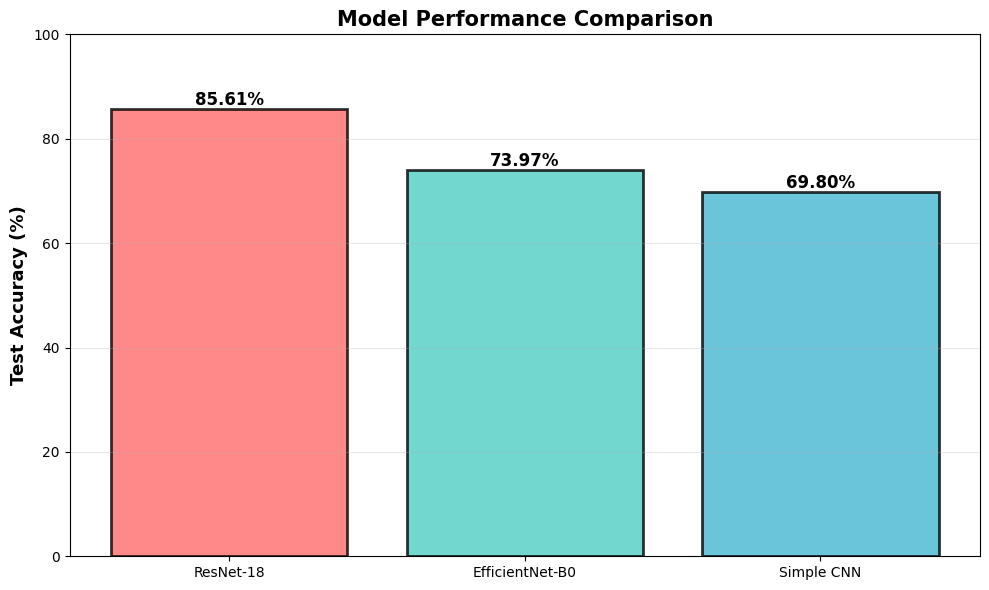

✓ Saved accuracy comparison chart


In [16]:
# Bar chart: Accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = comparison['Model'].values
accuracies = comparison['Accuracy (%)'].values
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(data_path + 'phase4_accuracy_comparison.png', dpi=150)
plt.show()

print("✓ Saved accuracy comparison chart")

### Visualization: Accuracy vs Parameters

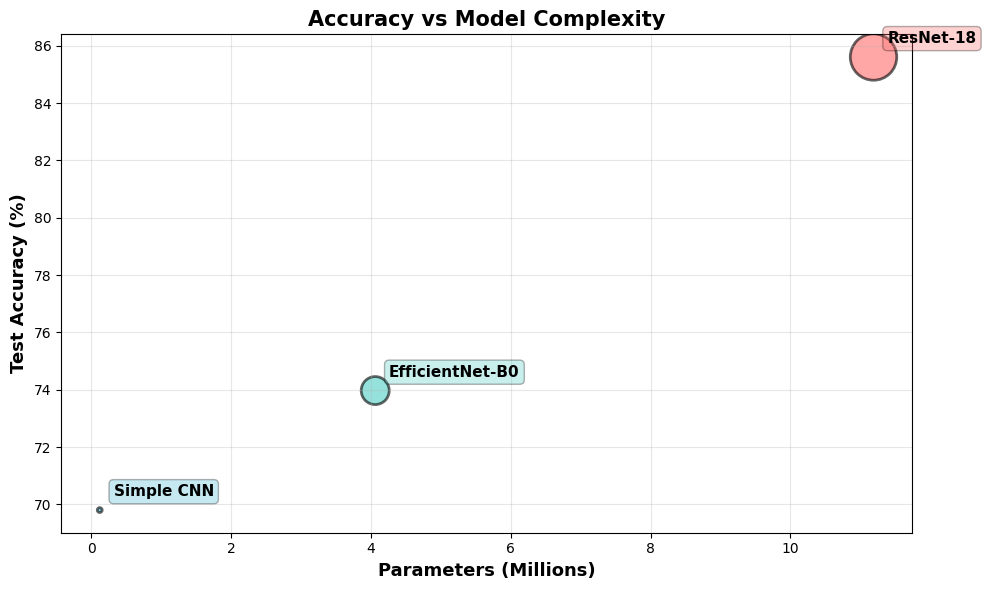

✓ Saved accuracy vs parameters chart


In [17]:
# Scatter plot: Accuracy vs Parameters
fig, ax = plt.subplots(figsize=(10, 6))

params = comparison['Parameters'].values / 1e6  # in millions
sizes = params * 100  # scale bubble sizes

scatter = ax.scatter(params, accuracies, s=sizes, c=colors, alpha=0.6,
                    edgecolors='black', linewidth=2)

for i, model in enumerate(models):
    ax.annotate(model, (params[i], accuracies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=colors[i], alpha=0.3))

ax.set_xlabel('Parameters (Millions)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Accuracy vs Model Complexity', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_path + 'phase4_accuracy_vs_params.png', dpi=150)
plt.show()

print("✓ Saved accuracy vs parameters chart")

### Confusion Matrices

<IPython.core.display.Javascript object>

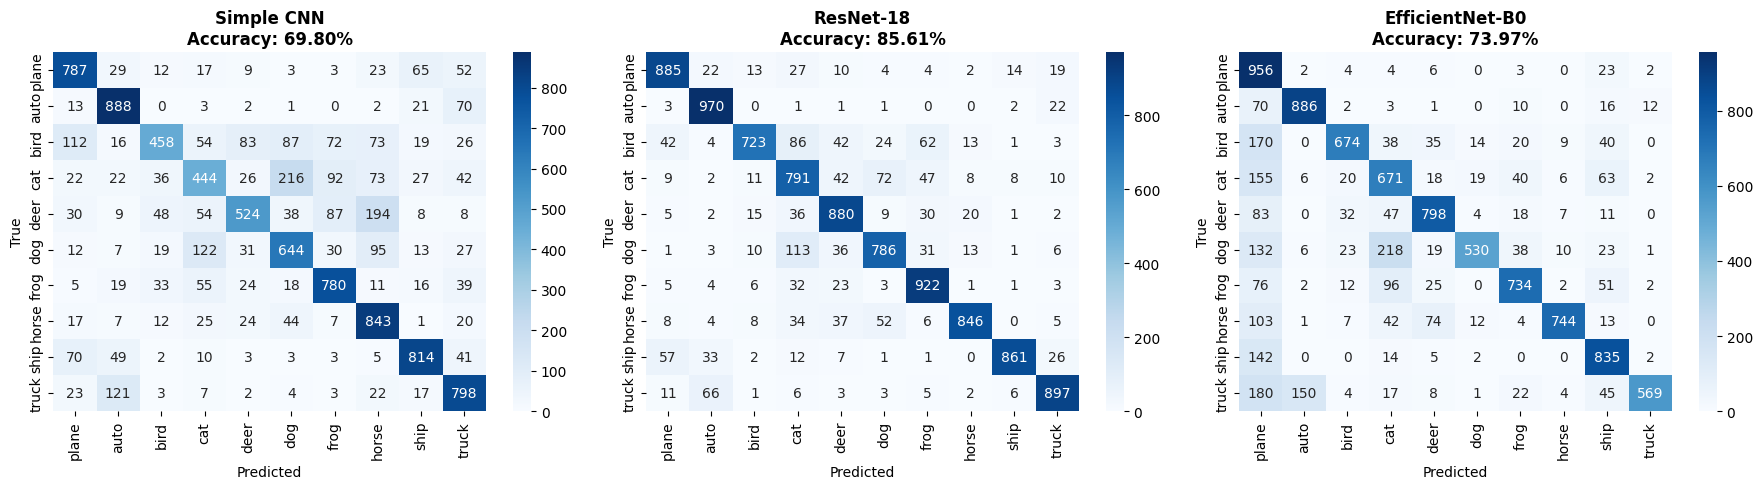

✓ Saved confusion matrices


In [18]:
# Generate confusion matrices
class_names = ['plane', 'auto', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
y_test_labels = np.argmax(y_test, axis=1)

models_dict = {
    'Simple CNN': simple_cnn,
    'ResNet-18': resnet18,
    'EfficientNet-B0': efficientnet
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_dict.items()):
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test_labels, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar=True)

    acc = comparison[comparison['Model'] == name]['Accuracy (%)'].values[0]
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig(data_path + 'phase4_confusion_matrices.png', dpi=150)
plt.show()

print("✓ Saved confusion matrices")

---
## Summary & Files Generated

In [21]:
print("="*80)
print("PHASE 4 COMPLETE")
print("="*80)

print("\nFINAL RESULTS:")
print(comparison.to_string(index=False))

print("\nFILES SAVED TO GOOGLE DRIVE:")
print("  Models:")
print("    - simple_cnn_best.h5")
print("    - resnet18_best.h5")
print("  Data:")
print("    - phase4_comparison.csv")
print("  Visualizations:")
print("    - phase4_accuracy_comparison.png")
print("    - phase4_accuracy_vs_params.png")
print("    - phase4_confusion_matrices.png")



PHASE 4 COMPLETE

FINAL RESULTS:
 Rank           Model  Accuracy (%)     Loss  Parameters
    1       ResNet-18     85.610002 0.474123    11188362
    2 EfficientNet-B0     73.970002 0.934301     4062381
    3      Simple CNN     69.800001 0.895977      122570

FILES SAVED TO GOOGLE DRIVE:
  Models:
    - simple_cnn_best.h5
    - resnet18_best.h5
  Data:
    - phase4_comparison.csv
  Visualizations:
    - phase4_accuracy_comparison.png
    - phase4_accuracy_vs_params.png
    - phase4_confusion_matrices.png

Ready to write Phase 4 report!
